In [29]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sumithsingh/blood-cell-images-for-cancer-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'blood-cell-images-for-cancer-detection' dataset.
Path to dataset files: /kaggle/input/blood-cell-images-for-cancer-detection


In [30]:
ls /kaggle/input/blood-cell-images-for-cancer-detection

basophil/  erythroblast/  monocyte/  myeloblast/  seg_neutrophil/


Install libraries

In [31]:
!pip install tensorflow opencv-python matplotlib

Load Dataset

In [32]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = "/kaggle/input/blood-cell-images-for-cancer-detection"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 4000 images belonging to 5 classes.
Found 1000 images belonging to 5 classes.


Check the Images

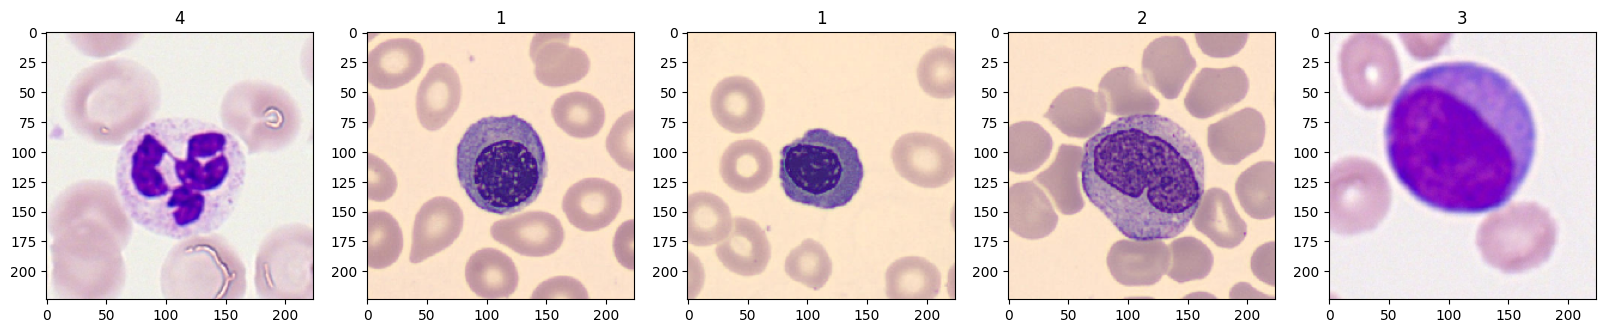

In [33]:
import os
import cv2
import imghdr
import matplotlib.pyplot as plt
import numpy as np

data_dir = "/kaggle/input/blood-cell-images-for-cancer-detection"

image_exts = ['jpeg', 'jpg', 'png', 'bmp']

for image_class in os.listdir(data_dir):
    class_path = os.path.join(data_dir, image_class)

    if not os.path.isdir(class_path):
        continue

    for image in os.listdir(class_path):
        image_path = os.path.join(class_path, image)

        try:
            img = cv2.imread(image_path)

            if img is None:
                print(f"Corrupt image: {image_path}")
                continue

            tip = imghdr.what(image_path)

            if tip not in image_exts:
                print(f"Invalid format: {image_path}")

        except:
            print(f"Issue with image: {image_path}")

# Get batch
batch = next(train_data)

# Plot
fig, ax = plt.subplots(ncols=5, figsize=(20,20))

for idx, img in enumerate(batch[0][:5]):
    ax[idx].imshow((img * 255).astype('uint8'))
    ax[idx].set_title(np.argmax(batch[1][idx]))

plt.show()

Build CNN model

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(5, activation='softmax'))  # 5 classes

Combile Model

In [35]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Train Model

In [36]:

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - accuracy: 0.6718 - loss: 0.8048 - val_accuracy: 0.8790 - val_loss: 0.3626
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.8355 - loss: 0.4016 - val_accuracy: 0.9050 - val_loss: 0.3269
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.8995 - loss: 0.2927 - val_accuracy: 0.9110 - val_loss: 0.2673
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.9250 - loss: 0.2198 - val_accuracy: 0.9270 - val_loss: 0.2174
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.9377 - loss: 0.1829 - val_accuracy: 0.9250 - val_loss: 0.2027
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.9477 - loss: 0.1614 - val_accuracy: 0.9510 - val_loss: 0.1457
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.9540 - loss: 0.1369 - val_accuracy: 0.9630 - val_loss: 0.1233
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.9555 - loss: 0.1437 -

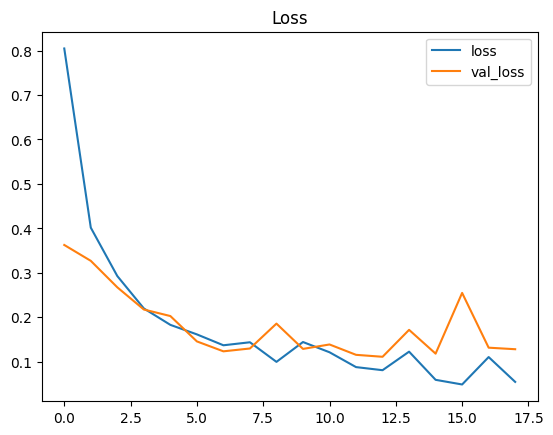

In [37]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss')
plt.show()

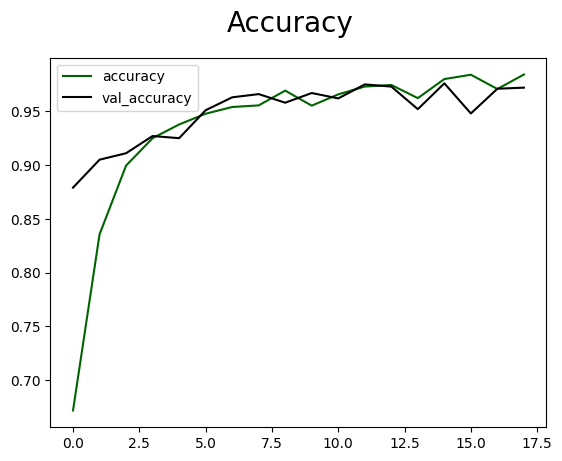

In [38]:
fig = plt.figure()
plt.plot(history.history['accuracy'], color='darkgreen', label='accuracy')
plt.plot(history.history['val_accuracy'], color='k', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

Save model

In [39]:
model.save("blood_cell_model.h5")

In [42]:
img_path = "/content/images (3).jpg"

Predict Model

In [43]:
import numpy as np
import cv2
from tensorflow.keras.models import load_model

# Load model
model = load_model("blood_cell_model.h5")

# Class names (adjust if needed)
class_names = list(train_data.class_indices.keys())

def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))
    img = img / 255.0
    img = np.reshape(img, (1,224,224,3))

    pred = model.predict(img)
    return class_names[np.argmax(pred)]

In [44]:
result = predict_image("/content/images (3).jpg")
print("Prediction:", result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: basophil
